In [1]:
#%pip install yfinance

[*********************100%***********************]  1 of 1 completed


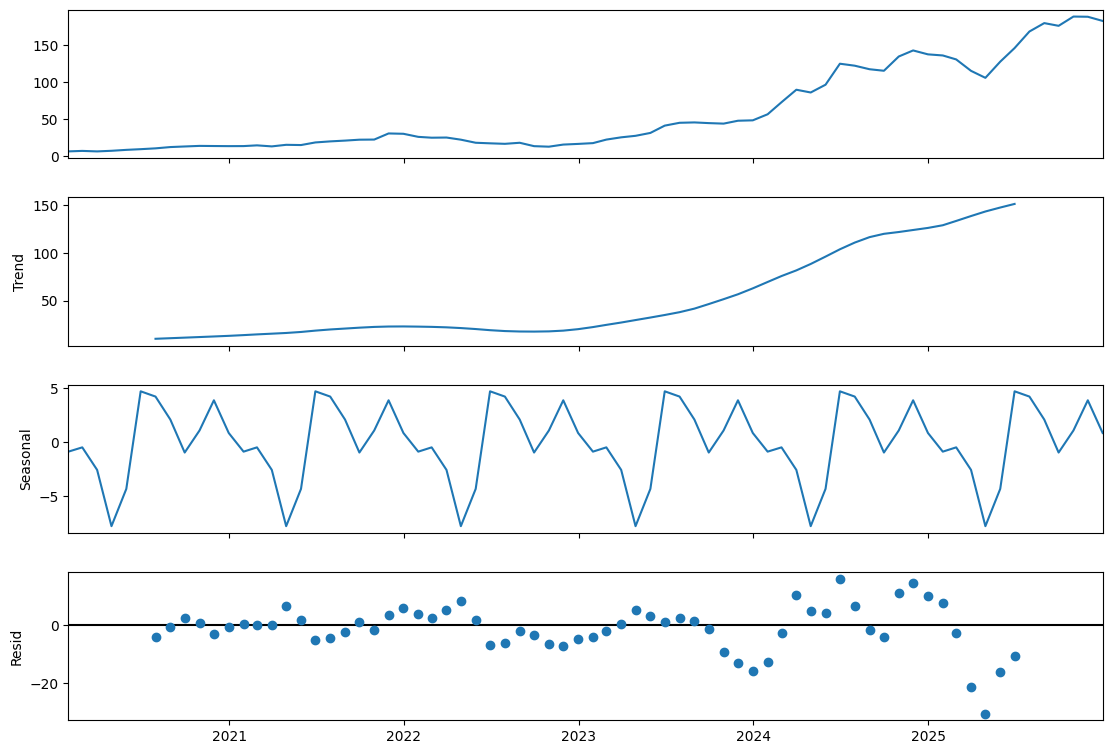

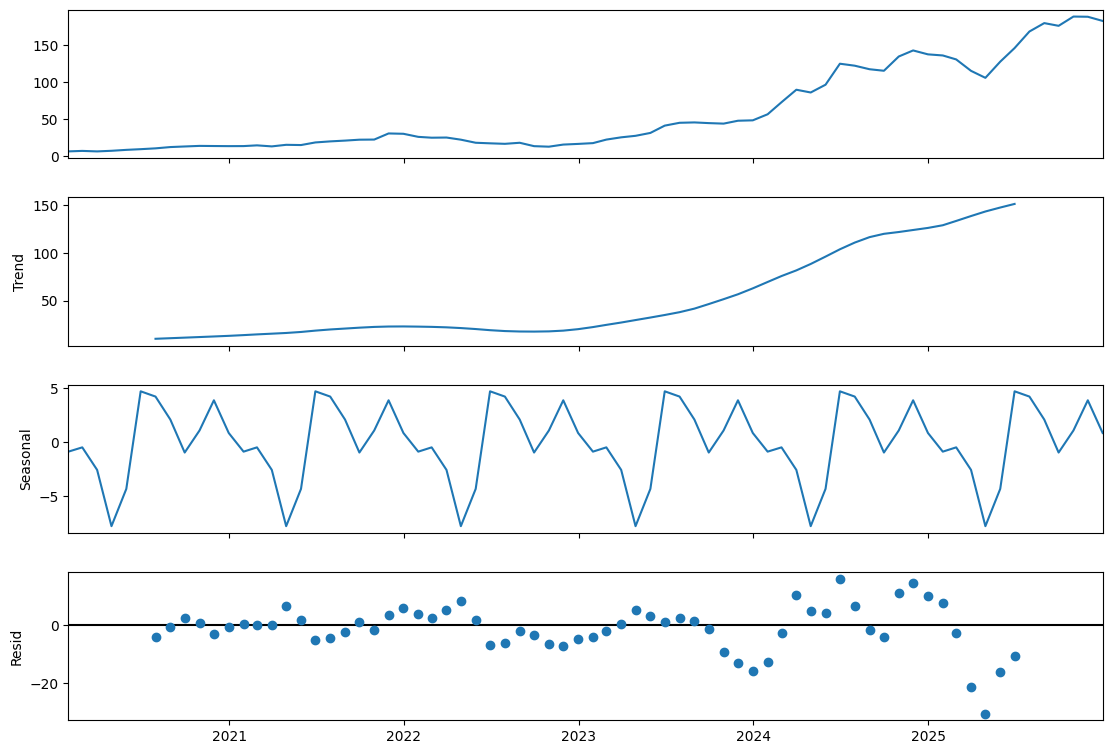

[*********************100%***********************]  1 of 1 completed


In [5]:
#!pip install yfinance
import yfinance as yf
from statsmodels.tsa.seasonal import seasonal_decompose
# descargar una serie temporal usando yf
# descomponer la serie 
#%pip install --upgrade pip
#%pip install yfinance statsmodels
 
#%pip install matplotlib
#!pip install yfinance
import matplotlib.pyplot as plt

nvidia = yf.download("NVDA", start="2020-01-01", end="2026-01-01")
serie_temporal = nvidia['Close'].resample('ME').mean()
descomposicion = seasonal_decompose(serie_temporal, model='additive', period=12)

fig = descomposicion.plot()
fig.set_size_inches(12, 8)
plt.show()
fig = descomposicion.plot()
fig.set_size_inches(12, 8)
plt.show()
nvidia = yf.download("NVDA", start="2020-01-01", end="2026-01-01")

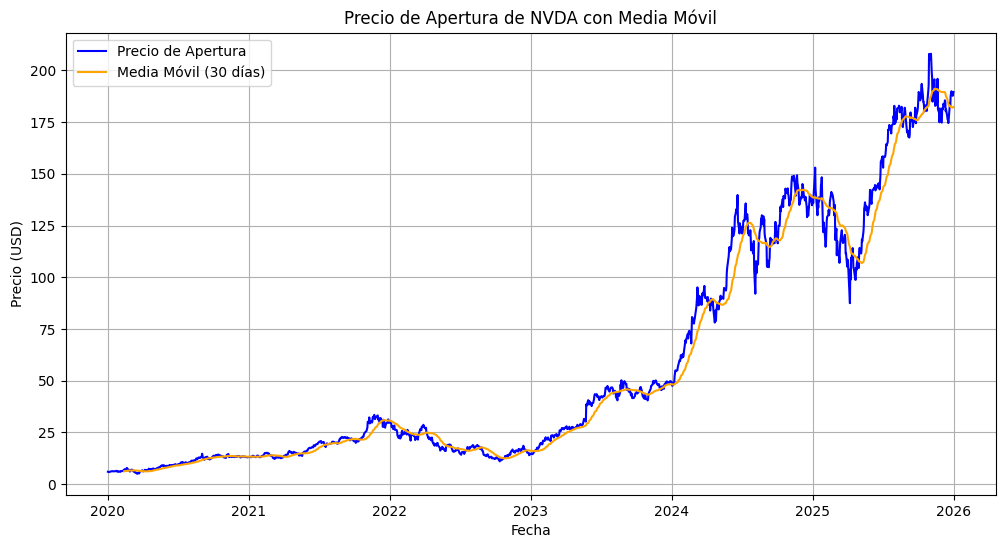

In [6]:
medias_moviles = nvidia['Open'].rolling(window=30).mean()

plt.figure(figsize=(12, 6))

plt.plot(nvidia['Open'], label='Precio de Apertura', color='blue')

plt.plot(medias_moviles, label='Media Móvil (30 días)', color='orange')

plt.title('Precio de Apertura de NVDA con Media Móvil')

plt.xlabel('Fecha')

plt.ylabel('Precio (USD)')

plt.legend()

plt.grid()

plt.show()

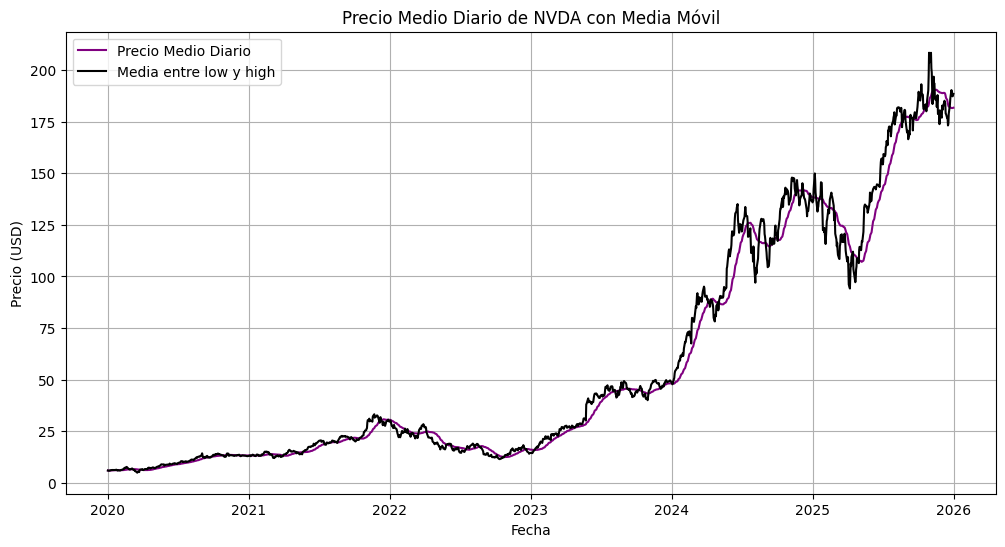

In [10]:
# Aplanar el MultiIndex de columnas
nvidia.columns = nvidia.columns.get_level_values(0)
 
# Ahora el cálculo funciona
nvidia['Precio_Medio'] = (nvidia['High'] + nvidia['Low']) / 2
nvidia['MM30_Precio_Medio'] = nvidia['Precio_Medio'].rolling(window=30, min_periods=1).mean()
 
nvidia[['High', 'Low', 'Precio_Medio', 'MM30_Precio_Medio']].head(35)
 
 
plt.figure(figsize=(12, 6))
plt.plot(nvidia['MM30_Precio_Medio'], label='Precio Medio Diario', color='purple')
plt.plot(nvidia['Precio_Medio'], label='Media entre low y high', color='black')
plt.title('Precio Medio Diario de NVDA con Media Móvil')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid()
plt.show()
 

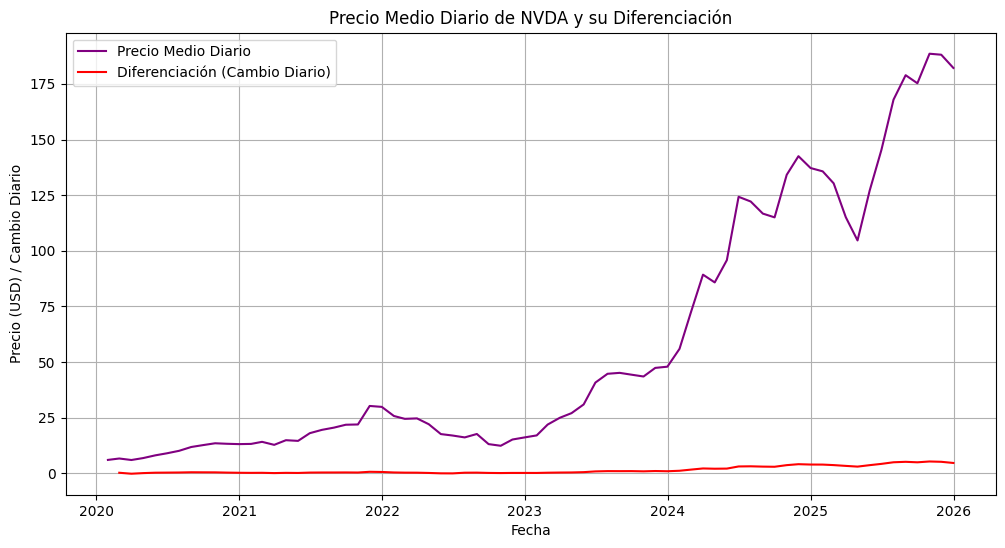

In [12]:
#precio medio moving average 30 dias
nvidia_mensual = nvidia.resample('ME').mean()
nvidia_mensual['MM30_Precio_Medio'] = nvidia_mensual['Precio_Medio'].rolling(window=30, min_periods=1).mean()
nvidia_mensual.head()
 
difenciacion = nvidia_mensual['MM30_Precio_Medio'].diff()
plt.figure(figsize=(12, 6))
plt.plot(nvidia_mensual.index, nvidia_mensual['Precio_Medio'], label='Precio Medio Diario', color='purple')
plt.plot(nvidia_mensual.index, difenciacion, label='Diferenciación (Cambio Diario)', color='red')
plt.title('Precio Medio Diario de NVDA y su Diferenciación')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD) / Cambio Diario')
plt.legend()
plt.grid()
plt.show()
 

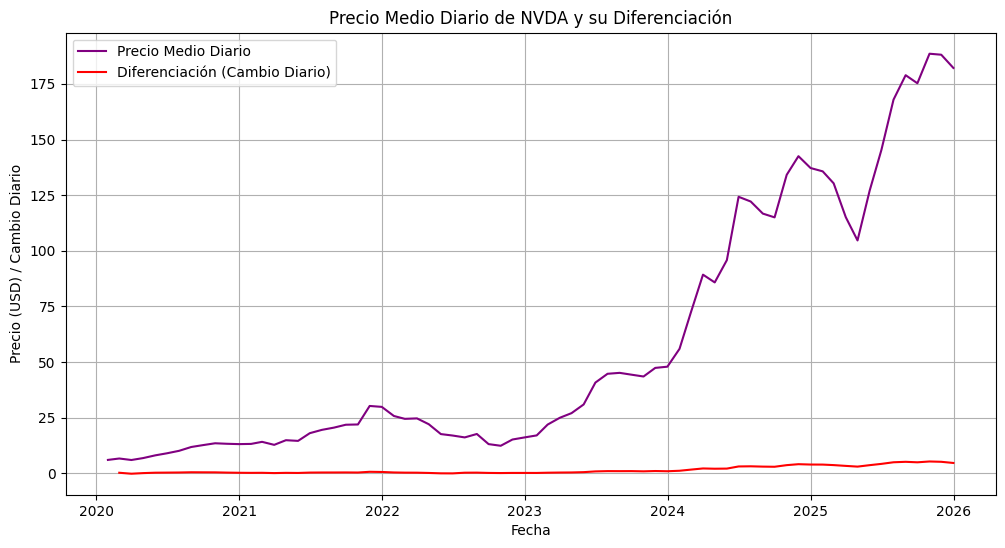

Price,Close,High,Low,Open,Volume,Precio_Medio,MM30_Precio_Medio
Date,,,,,,,
2020-01-31,6.092774,6.153334,6.016216,6.090665,2.916863e+08,6.084775,6.084775
2020-02-29,6.743239,6.858560,6.574634,6.675211,6.236133e+08,6.716597,6.400686
2020-03-31,6.065039,6.283285,5.803111,6.028183,7.169978e+08,6.043198,6.281523
2020-04-30,6.897871,7.062073,6.753260,6.912065,5.370621e+08,6.907666,6.438059
2020-05-31,8.151851,8.298575,7.966104,8.116477,6.274438e+08,8.132339,6.776915


In [13]:
#precio medio moving average 30 dias
nvidia_mensual['MM30_Precio_Medio'] = nvidia_mensual['Precio_Medio'].rolling(window=30, min_periods=1).mean()
nvidia_mensual.head()
 
difenciacion = nvidia_mensual['MM30_Precio_Medio'].diff()
plt.figure(figsize=(12, 6))
plt.plot(nvidia_mensual.index, nvidia_mensual['Precio_Medio'], label='Precio Medio Diario', color='purple')
plt.plot(nvidia_mensual.index, difenciacion, label='Diferenciación (Cambio Diario)', color='red')
plt.title('Precio Medio Diario de NVDA y su Diferenciación')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD) / Cambio Diario')
plt.legend()
plt.grid()
plt.show()
 
nvidia_mensual['MM30_Precio_Medio'] = nvidia_mensual['Precio_Medio'].rolling(window=30, min_periods=1).mean()
nvidia_mensual.head()
 

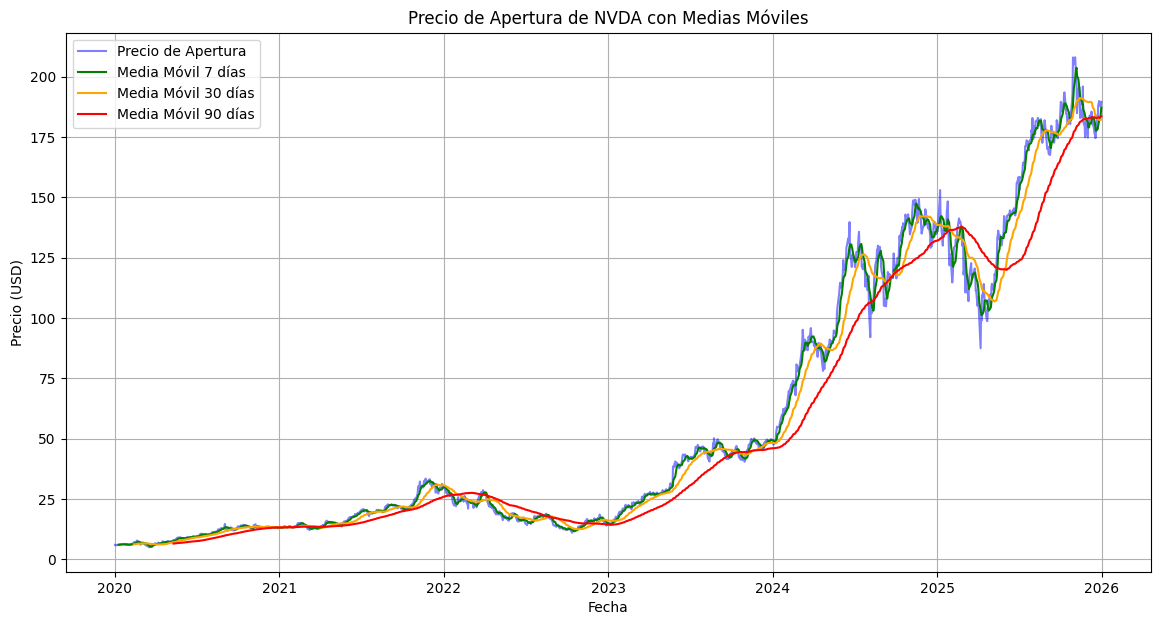

In [15]:
# Probá distintas ventanas:
medias_moviles_7 = nvidia['Open'].rolling(window=7).mean()   # 1 semana
medias_moviles_30 = nvidia['Open'].rolling(window=30).mean()  # 1 mes
medias_moviles_90 = nvidia['Open'].rolling(window=90).mean()  # 3 meses

import matplotlib.pyplot as plt

# Calcular las medias móviles
mm_7 = nvidia['Open'].rolling(window=7).mean()
mm_30 = nvidia['Open'].rolling(window=30).mean()
mm_90 = nvidia['Open'].rolling(window=90).mean()

# Graficar
plt.figure(figsize=(14, 7))
plt.plot(nvidia['Open'], label='Precio de Apertura', color='blue', alpha=0.5)
plt.plot(mm_7, label='Media Móvil 7 días', color='green')
plt.plot(mm_30, label='Media Móvil 30 días', color='orange')
plt.plot(mm_90, label='Media Móvil 90 días', color='red')
plt.title('Precio de Apertura de NVDA con Medias Móviles')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid()
plt.show()

[*********************100%***********************]  1 of 1 completed


--- Precio Medio Diario ---
Estadístico ADF = 1.1553
p-valor = 0.9957
Nº observaciones usadas = 1606
Veredicto: NO es estacionaria (conviene diferenciar) ❌

--- Precio Medio Diferenciado ---
Estadístico ADF = -7.2890
p-valor = 0.0000
Nº observaciones usadas = 1586
Veredicto: ES estacionaria ✅



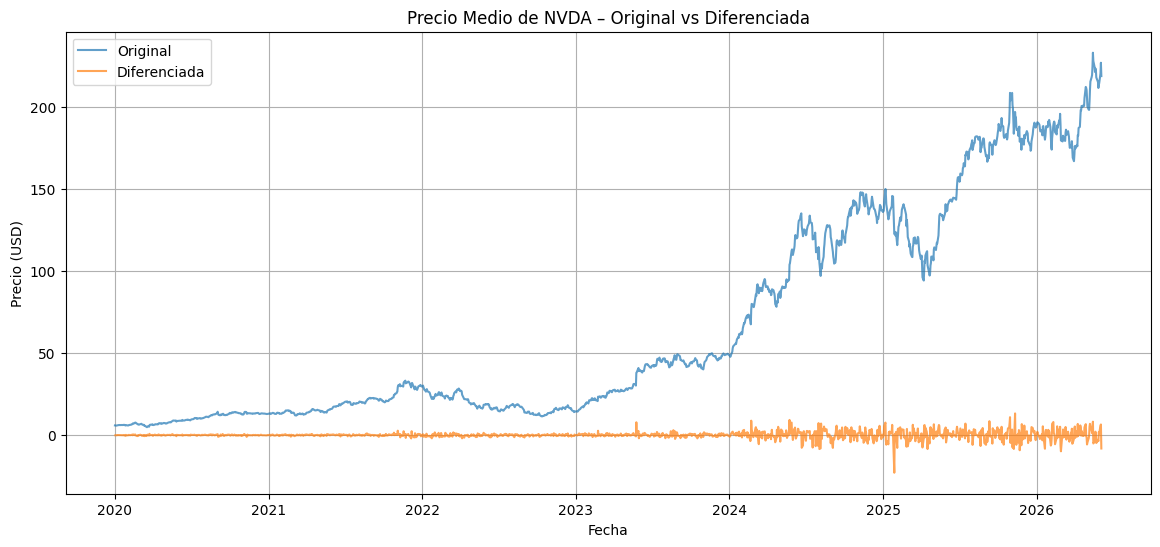

In [1]:
# ============================================================
# 1. Importar librerías
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import adfuller

# ============================================================
# 2. Descargar datos de NVDA
# ============================================================
nvidia = yf.download("NVDA", start="2020-01-01", end="2026-06-04")

# Aplanar el MultiIndex de columnas (si existe)
nvidia.columns = nvidia.columns.get_level_values(0)

# Crear el Precio Medio (High + Low) / 2
nvidia['Precio_Medio'] = (nvidia['High'] + nvidia['Low']) / 2

# ============================================================
# 3. Definir la función del profesor
# ============================================================
def test_estacionariedad(serie_a_probar, nombre):
    resultado = adfuller(serie_a_probar.dropna())
    p_valor = resultado[1]
    print(f"--- {nombre} ---")
    print(f"Estadístico ADF = {resultado[0]:.4f}")
    print(f"p-valor = {p_valor:.4f}")
    print(f"Nº observaciones usadas = {resultado[3]}")
    if p_valor <= 0.05:
        print("Veredicto: ES estacionaria ✅\n")
    else:
        print("Veredicto: NO es estacionaria (conviene diferenciar) ❌\n")

# ============================================================
# 4. Aplicar el test a la serie original y a la diferenciada
# ============================================================
serie = nvidia['Precio_Medio'].dropna()

# Test sobre la serie original
test_estacionariedad(serie, "Precio Medio Diario")

# Test sobre la serie diferenciada (primer diferencia)
serie_dif = serie.diff().dropna()
test_estacionariedad(serie_dif, "Precio Medio Diferenciado")

# ============================================================
# 5. (Opcional) Graficar ambas series
# ============================================================
plt.figure(figsize=(14, 6))
plt.plot(serie.index, serie, label='Original', alpha=0.7)
plt.plot(serie_dif.index, serie_dif, label='Diferenciada', alpha=0.7)
plt.title('Precio Medio de NVDA – Original vs Diferenciada')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid()
plt.show()

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1291
Model:               SARIMAX(4, 1, 2)   Log Likelihood               -2424.154
Date:                Wed, 03 Jun 2026   AIC                           4862.308
Time:                        20:02:23   BIC                           4898.445
Sample:                             0   HQIC                          4875.872
                               - 1291                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.5430      0.051    -30.171      0.000      -1.643      -1.443
ar.L2         -0.5505      0.043    -12.750      0.000      -0.635      -0.466
ar.L3          0.0181      0.029      0.621      0.5

c:\Users\Randy Bonucci Martín\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Randy Bonucci Martín\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


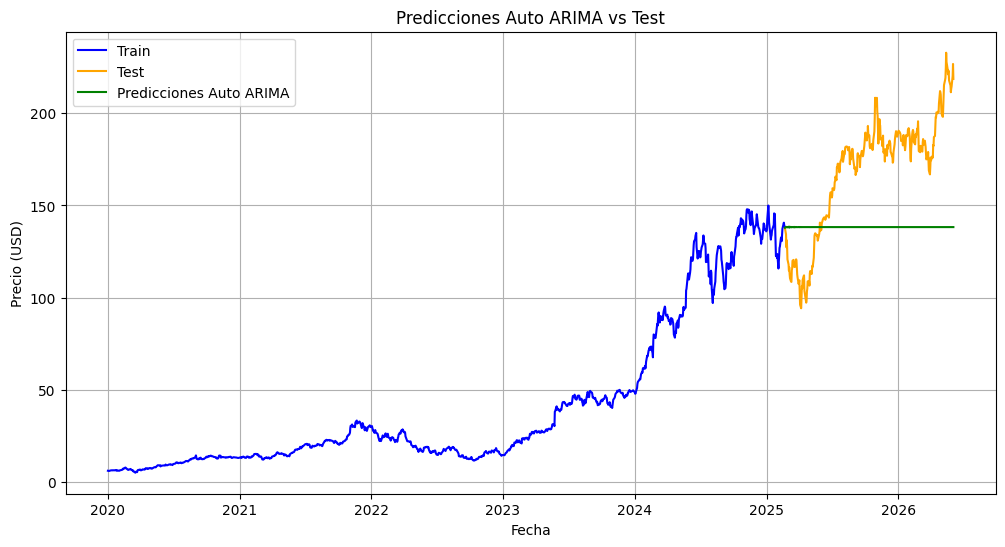

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1291
Model:               SARIMAX(4, 1, 2)   Log Likelihood               -2424.154
Date:                Wed, 03 Jun 2026   AIC                           4862.308
Time:                        20:02:23   BIC                           4898.445
Sample:                             0   HQIC                          4875.872
                               - 1291                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.5430      0.051    -30.171      0.000      -1.643      -1.443
ar.L2         -0.5505      0.043    -12.750      0.000      -0.635      -0.466
ar.L3          0.0181      0.029      0.621      0.5

c:\Users\Randy Bonucci Martín\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Randy Bonucci Martín\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


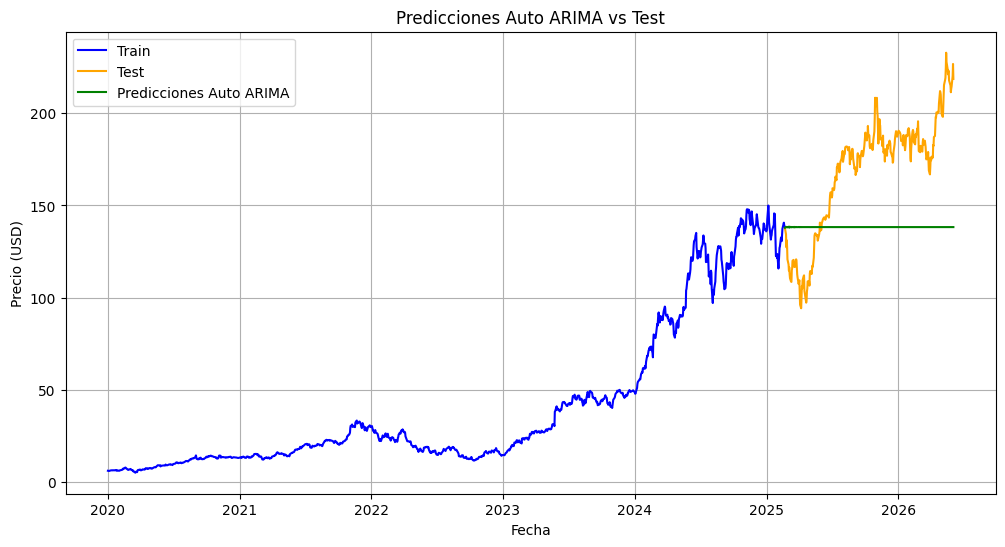

In [5]:
import pmdarima as pm

#%pip install pmdarima
#%pip install pmdarima

# Definir train/test sobre la serie existente
n_test = max(1, int(len(serie) * 0.2))
train = serie.iloc[:-n_test]
test = serie.iloc[-n_test:]

modelo_auto_arima = pm.auto_arima(train, seasonal=False, stepwise=True)
print(modelo_auto_arima.summary())
predicciones_auto_arima = modelo_auto_arima.predict(n_periods=n_test)
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Train', color='blue')
plt.plot(test.index, test, label='Test', color='orange')
plt.plot(test.index, predicciones_auto_arima, label='Predicciones Auto ARIMA', color='green')
plt.title('Predicciones Auto ARIMA vs Test')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid()
plt.show()
print(modelo_auto_arima.summary())
predicciones_auto_arima = modelo_auto_arima.predict(n_periods=n_test)
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Train', color='blue')
plt.plot(test.index, test, label='Test', color='orange')
plt.plot(test.index, predicciones_auto_arima, label='Predicciones Auto ARIMA', color='green')
plt.title('Predicciones Auto ARIMA vs Test')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid()
plt.show()

In [7]:
#%pip install --upgrade --force-reinstall numpy
#%pip install --upgrade --force-reinstall pmdarima statsmodels
 
import pmdarima as pm
modelo_auto = pm.auto_arima(train,
                            seasonal=True, m=12,   # m=12 = ciclo anual
                            trace=True,            # muestra lo que va probando
                            stepwise=True)         # búsqueda inteligente (más rápida)
print(modelo_auto.summary())
pred_auto = modelo_auto.predict(n_periods=n_test)
 

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=2.92 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=4913.467, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=4879.690, Time=0.23 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=4875.489, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=4916.646, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=4874.102, Time=0.10 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=4875.572, Time=0.24 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=0.91 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=4875.050, Time=0.15 sec
 ARIMA(0,1,2)(0,0,0)[12] intercept   : AIC=4874.761, Time=0.12 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=4878.351, Time=0.06 sec
 ARIMA(1,1,2)(0,0,0)[12] intercept   : AIC=4873.732, Time=0.67 sec
 ARIMA(1,1,2)(1,0,0)[12] intercept   : AIC=4875.072, Time=1.89 sec
 ARIMA(1,1,2)(0,0,1)[12] intercept   : AIC=4874.961, Time=2.18 sec
 ARIMA(1,1,2)(1,0,1)[12] inte

c:\Users\Randy Bonucci Martín\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Randy Bonucci Martín\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
